<a href="https://colab.research.google.com/github/Shibli-Nomani/PCA_Project_over_Breast_Cancer_Digit_Recognition_Dataset/blob/main/PCA_Project_over_Breast_Cancer_Digit_Recognition_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Khan Md Shibli Nomani**


# Project Title: Principal Component Analysis for Dimensionality Reduction: A Comparative Study of Feature Structure and Classification Performance

## Abstract:
This study investigated how Principal Component Analysis (PCA) affected dimensionality reduction and classification performance using the Breast Cancer and Digits datasets. The datasets were selected because they had different feature structures. Pearson correlation, KMO, and Bartlett's test were used to analyse relationships among the features. PCA was applied after standardisation using different numbers of principal components, while the same Logistic Regression classifier was used before and after PCA for comparison. The evaluation considered explained variance, classification accuracy, F1-score, dimensionality reduction, training time, and reconstruction error. For the Breast Cancer dataset, 10 components retained 95.27% of the variance with 66.67% dimensionality reduction and achieved 96.49% test accuracy. For the Digits dataset, 50 components retained 98.33% of the variance with 21.88% dimensionality reduction and achieved 96.67% test accuracy. The results showed that PCA effectiveness depended on the feature structure of the dataset, and selecting the number of components required a balance between information retention, classification performance, and dimensionality reduction.

## Datasets: Breast Cancer {0/1} and Digits {0-9} datasets Loaded from sklearn





## Install required Libraries


In [ ]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42657 sha256=af78679dc0766b18b879d4d8b688c1c92efef648ad2adfcd9a479744cad95be3
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [ ]:
# =============================================================================
# STANDARD LIBRARY IMPORTS
# =============================================================================
from time import perf_counter
import warnings

# =============================================================================
# THIRD-PARTY DATA & VISUALIZATION IMPORTS
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

# =============================================================================
# SCIKIT-LEARN IMPORTS
# =============================================================================
# Datasets
from sklearn.datasets import (
    load_breast_cancer,
    load_digits,
)

# Model Selection & Validation
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)

# Preprocessing & Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Estimators
from sklearn.linear_model import LogisticRegression

# Performance Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# =============================================================================
# FACTOR ANALYSIS & STATISTICAL TESTS
# =============================================================================
from factor_analyzer.factor_analyzer import (
    calculate_bartlett_sphericity,
    calculate_kmo,
)

# =============================================================================
# CONFIGURATION & WARNINGS
# =============================================================================
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="sklearn.linear_model._logistic"
)

## Load breast_cancer Data


In [ ]:
breast_cancer = load_breast_cancer()

df_bcancer = pd.DataFrame(breast_cancer.data)
df_bcancer.columns = breast_cancer.feature_names
df_bcancer['target'] = breast_cancer.target
df_bcancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Load Digit data

In [ ]:

digits = load_digits()
df_digits = pd.DataFrame(digits.data)
df_digits.columns = digits.feature_names
df_digits['target'] = digits.target

df_digits.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


## About Datasets (Breast Cancer and Digits)

In [ ]:

print(f"Dataset Shape of Breast cancer: {df_bcancer.shape}")
print(f"Dataset Shape of Digits:        {df_digits.shape}")

print("-" * 40) # Visual separator


print("Null Status for Breast Cancer:")
print(df_bcancer.isnull().sum().sum())

print("\nNull Status for Digits:")
print(df_digits.isnull().sum().sum())

Dataset Shape of Breast cancer: (569, 31)
Dataset Shape of Digits:        (1797, 65)
----------------------------------------
Null Status for Breast Cancer:
0

Null Status for Digits:
0


In [ ]:
# Dataset Summary
summary = pd.DataFrame({
    "Dataset": [
        "Breast Cancer",
        "Digits"
    ],
    "Samples": [
        df_bcancer.shape[0],
        df_digits.shape[0]
    ],
    "Features": [
        df_bcancer.shape[1],
        df_digits.shape[1]
    ],
    "Classes": [
        np.unique(df_bcancer["target"]),
        np.unique(df_digits["target"])
    ],
    "Missing Values": [
        df_bcancer.isna().sum().sum(),
        df_digits.isna().sum().sum()
    ]
})

summary

,Dataset,Samples,Features,Classes,Missing Values
0,Breast Cancer,569,31,"[0, 1]",0
1,Digits,1797,65,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",0


## Train and Test Split

In [ ]:
# train and test
def train_test_spliter(df, df_name = None):
  X = df.copy()
  X = X.drop("target", axis=1)
  y=df['target']


  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.20, random_state=42, stratify=y)

  print(f" Shape Features of {df_name} Train: {X_train.shape}")
  print(f" Shape Target of {df_name} Train: {y_train.shape}")
  print(f" Number of Target clases {df_name} Train: {np.unique(y_train)}")
  print(f" Shape Features of {df_name} Test: {X_test.shape}")
  print(f" Shape Target of {df_name} Train: {y_test.shape}")

  print(f"{50*"="}")




  return X_train, X_test, y_train, y_test

In [ ]:

X_bcancer_train, X_bcancer_test, y_bcancer_train, y_bcancer_test = train_test_spliter(df_bcancer, df_name="Breast Cancer")
X_digits_train, X_digits_test, y_digits_train, y_digits_test = train_test_spliter(df_digits, df_name="Digits")



 Shape Features of Breast Cancer Train: (455, 30)
 Shape Target of Breast Cancer Train: (455,)
 Number of Target clases Breast Cancer Train: [0 1]
 Shape Features of Breast Cancer Test: (114, 30)
 Shape Target of Breast Cancer Train: (114,)
 Shape Features of Digits Train: (1437, 64)
 Shape Target of Digits Train: (1437,)
 Number of Target clases Digits Train: [0 1 2 3 4 5 6 7 8 9]
 Shape Features of Digits Test: (360, 64)
 Shape Target of Digits Train: (360,)


## Pearsons Corelation of Features for breast canncer and digits

In [ ]:
# Breast Cancer
X_train_corr_bcancer = X_bcancer_train.corr(method="pearson")


# Digits
X_train_corr_digits = X_digits_train.corr(method="pearson")
X_train_corr_digits = X_train_corr_digits.fillna(0.0)

In [ ]:
X_train_corr_bcancer.head(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.000000,0.314532,0.997789,0.988886,0.186062,0.515946,0.668475,0.822570,0.163217,-0.300273,...,0.970133,0.282822,0.965936,0.943351,0.119631,0.411654,0.524067,0.735769,0.175900,0.003668
mean texture,0.314532,1.000000,0.317985,0.309964,-0.041173,0.214740,0.276222,0.266221,0.055795,-0.083201,...,0.339574,0.912994,0.340889,0.331846,0.050191,0.254213,0.283289,0.268854,0.093769,0.107275
mean perimeter,0.997789,0.317985,1.000000,0.987834,0.224332,0.567508,0.709029,0.851740,0.200440,-0.248503,...,0.969674,0.287632,0.970918,0.943063,0.151513,0.454270,0.562180,0.763547,0.202702,0.048211
mean area,0.988886,0.309964,0.987834,1.000000,0.198963,0.512307,0.678012,0.824948,0.166673,-0.267226,...,0.962829,0.271958,0.959360,0.957080,0.131227,0.392119,0.511134,0.716582,0.157698,0.005322
mean smoothness,0.186062,-0.041173,0.224332,0.198963,1.000000,0.661769,0.550461,0.572164,0.570054,0.566008,...,0.231080,0.028475,0.258177,0.228156,0.798808,0.495236,0.473253,0.518242,0.430442,0.503625


In [ ]:
X_train_corr_digits.head(5)

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
pixel_0_0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
pixel_0_1,0.0,1.000000,0.563494,0.207655,0.006240,0.081577,0.062527,-0.040897,0.029460,0.563937,...,0.019092,-0.036628,-0.008721,0.854981,0.562132,0.159614,-0.094370,-0.033995,0.023977,-0.038615
pixel_0_2,0.0,0.563494,1.000000,0.553659,-0.074111,0.046375,-0.003516,-0.069339,0.036719,0.598597,...,0.055194,0.010635,-0.028900,0.512513,0.937893,0.506311,-0.126290,-0.035914,0.095110,0.102441
pixel_0_3,0.0,0.207655,0.553659,1.000000,0.025385,-0.169540,-0.113991,-0.038338,0.035146,0.326342,...,0.143384,0.075604,-0.054887,0.169677,0.550924,0.771275,-0.054445,-0.052719,0.066119,0.087393
pixel_0_4,0.0,0.006240,-0.074111,0.025385,1.000000,0.499459,0.128463,0.016499,0.042192,0.063107,...,-0.271288,-0.216254,0.019009,-0.023599,-0.010964,-0.006865,-0.083954,-0.222052,-0.244569,-0.199864


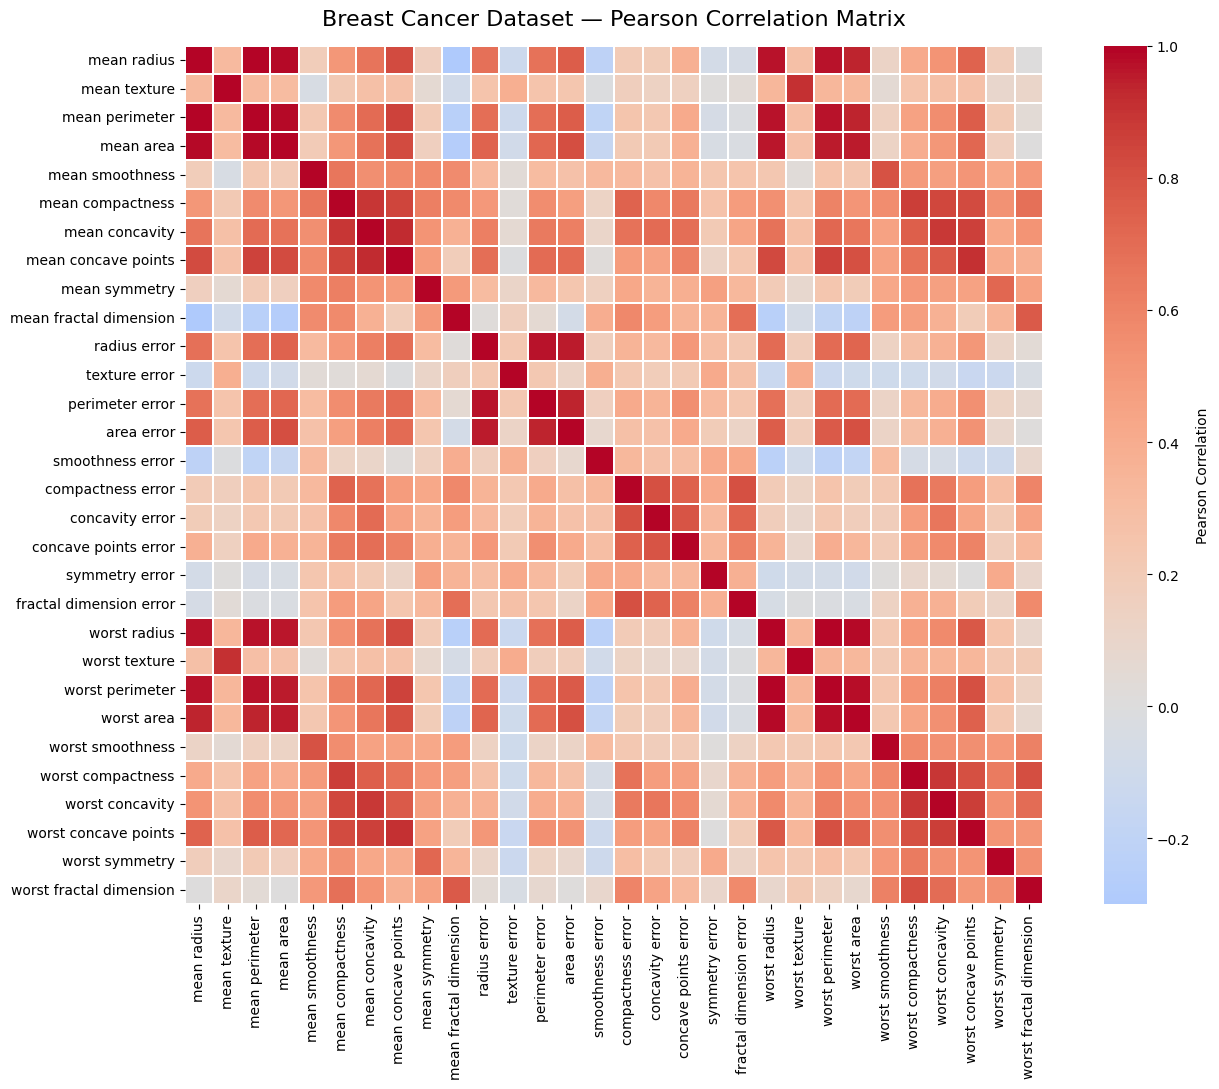

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(14, 11))

sns.heatmap(
    X_train_corr_bcancer,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={
        "label": "Pearson Correlation"
    }
)

plt.title(
    "Breast Cancer Dataset — Pearson Correlation Matrix",
    fontsize=16,
    pad=15
)

plt.tight_layout()
plt.show()

## Pearsons Correlation of Handwritten digit


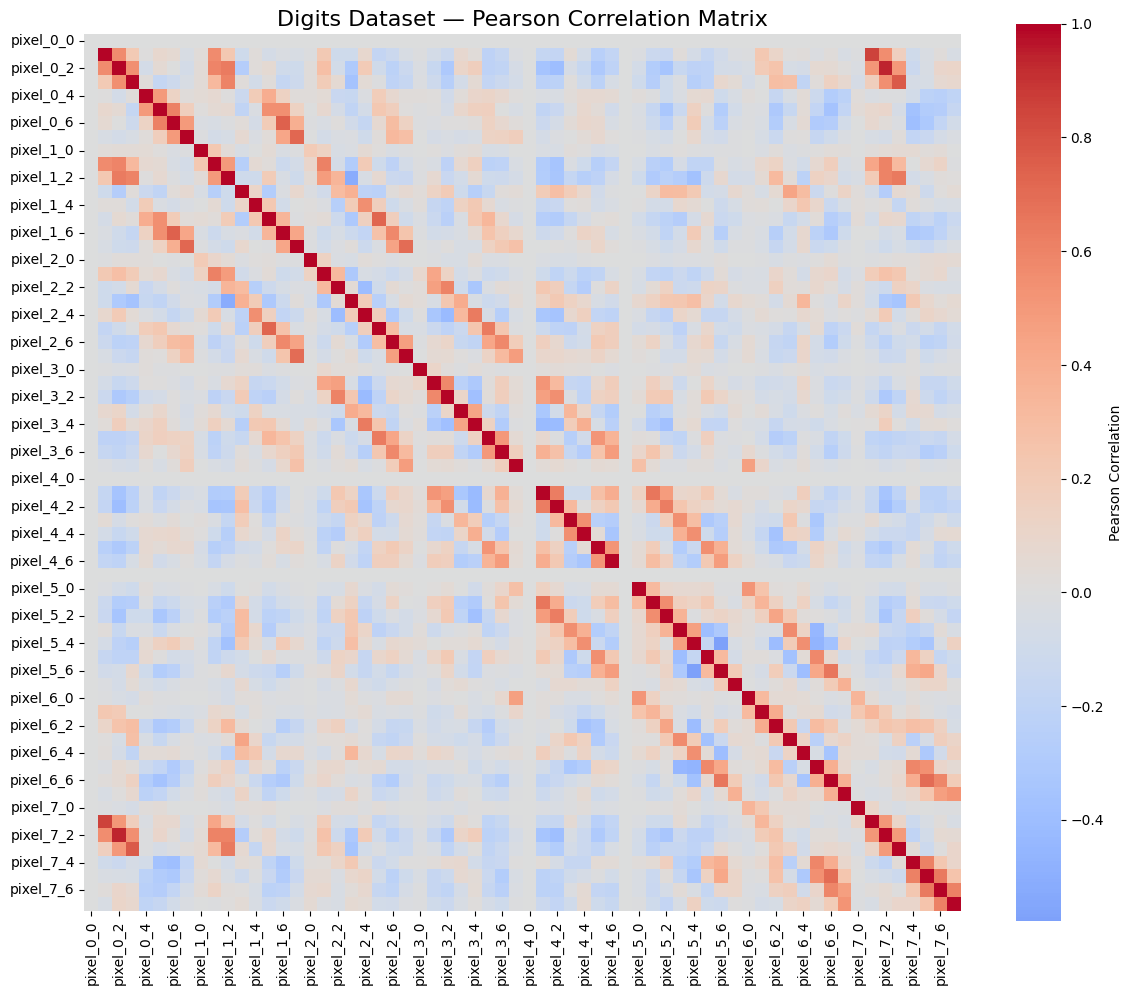

In [ ]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    X_train_corr_digits,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={
        "label": "Pearson Correlation"
    }
)

plt.title(
    "Digits Dataset — Pearson Correlation Matrix",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Combine Heatmap of Two dataset (Breast and Digits Dataset)

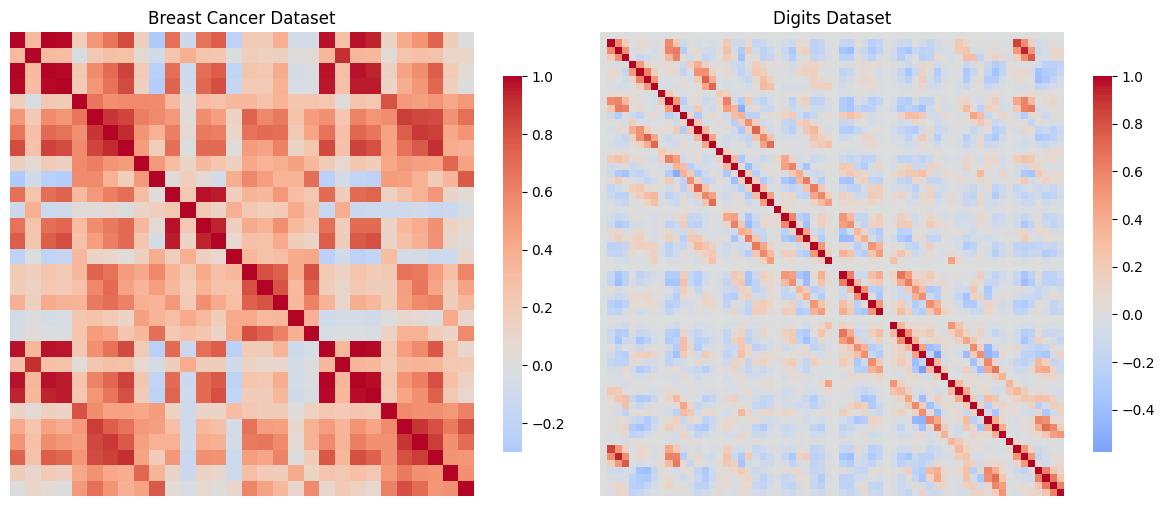

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Breast Cancer
sns.heatmap(
    X_train_corr_bcancer,
    ax=axes[0],
    cmap="coolwarm",
    center=0,
    square=True,
    xticklabels=False,
    yticklabels=False,
    linewidths=0,
    cbar=True,
    cbar_kws={"shrink": 0.8}
)

axes[0].set_title("Breast Cancer Dataset")

# Digits
sns.heatmap(
    X_train_corr_digits,
    ax=axes[1],
    cmap="coolwarm",
    center=0,
    square=True,
    xticklabels=False,
    yticklabels=False,
    linewidths=0,
    cbar=True,
    cbar_kws={"shrink": 0.8}
)

axes[1].set_title("Digits Dataset")

plt.tight_layout()
plt.show()

In [ ]:



def mean_absolute_correlation(df, name="Dataset"):
    corr = df.corr().values
    upper_triangle = corr[np.triu_indices_from(corr, k=1)]

    print(f"{name} Dataset")
    # nanmean ignores the NaN values instead of letting them break the calculation
    return np.nanmean(np.abs(upper_triangle))


print(mean_absolute_correlation(round(X_bcancer_train,4), "Breast Cancer"))
print(mean_absolute_correlation(round(X_digits_train,4), "Digits"))

Breast Cancer Dataset
0.3964372688756055
Digits Dataset
0.12406825475199555


In [ ]:
mean_corr_cancer = mean_absolute_correlation(X_bcancer_train, "Breast Cancer")
mean_corr_digits = mean_absolute_correlation(X_digits_train, "Digits")

print(
    "Breast Cancer:",
    round(mean_corr_cancer, 4, )
)

print(
    "Hand Written Digits:",
    round(mean_corr_digits, 4)
)

Breast Cancer Dataset
Digits Dataset
Breast Cancer: 0.3964
Hand Written Digits: 0.1241


# Correlation Distribution Chart

In [ ]:
def get_upper_correlations(df):

    corr = df.corr().values

    return corr[
        np.triu_indices_from(corr, k=1)
    ]

In [ ]:
corr_values_cancer = get_upper_correlations(X_bcancer_train)
corr_values_digits = get_upper_correlations(X_digits_train)

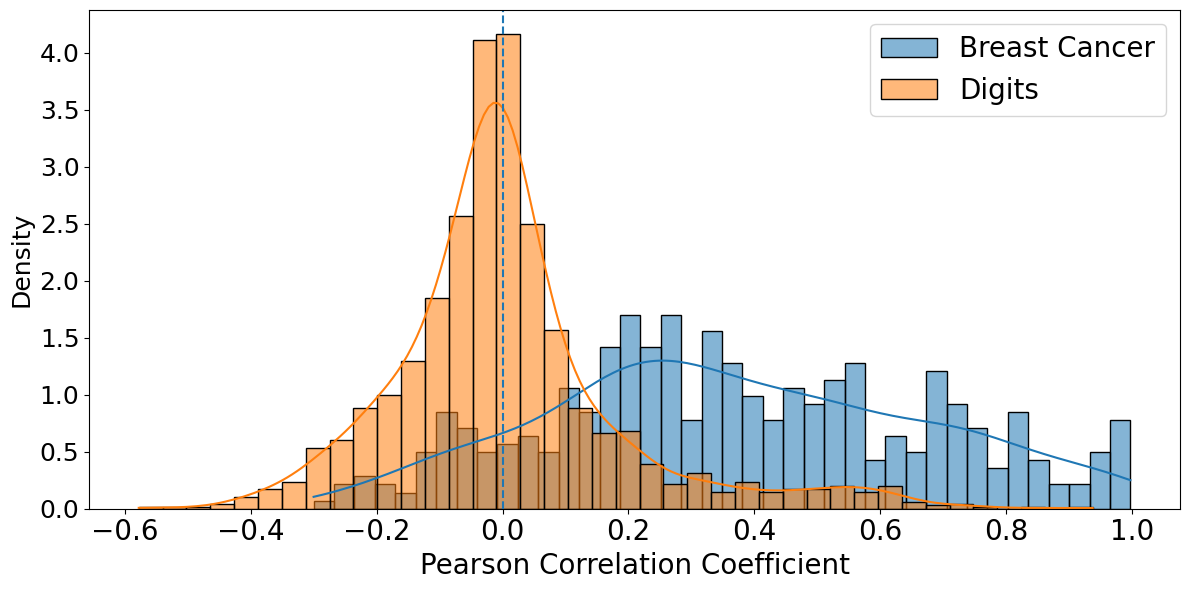

In [ ]:
## Correlation chart for Breast Cancer and Digit dataset
plt.figure(figsize=(12, 6))

sns.histplot(
    corr_values_cancer,
    bins=40,
    kde=True,
    stat="density",
    label="Breast Cancer",
    alpha=0.55
)

sns.histplot(
    corr_values_digits,
    bins=40,
    kde=True,
    stat="density",
    label="Digits",
    alpha=0.55
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

# Larger axis labels
plt.xlabel("Pearson Correlation Coefficient", fontsize=20)
plt.ylabel("Density", fontsize=18)

# Larger tick labels
plt.xticks(fontsize=20)
plt.yticks(fontsize=18)

#plt.title(
#    "Distribution of Pairwise Feature Correlations",
#    fontsize=16
#)

plt.legend(fontsize=20)
plt.tight_layout()
plt.show()

## KMO Test

In [ ]:
def run_kmo_test(X, dataset_name):
    # Fix: Drop columns where all values are identical (variance is 0)
    # to avoid division-by-zero errors that cause 'nan'
    X_clean = X.loc[:, X.var() != 0] if hasattr(X, 'var') else X

    kmo_per_feature, kmo_total = calculate_kmo(X_clean)

    print(f"\n{dataset_name}")
    print("-" * 40)
    print(
        f"Overall KMO: {kmo_total:.4f}"
    )

    return kmo_per_feature, kmo_total

The Kaiser-Meyer-Olkin (KMO) measure tells you whether your dataset is suitable for factor analysis or dimensionality reduction techniques that rely on shared underlying factors. It measures how much of the variance among variables is shared.

In [ ]:
kmo_cancer_features, kmo_cancer = run_kmo_test(
    X_bcancer_train,
    "Breast Cancer"
)

kmo_digits_features, kmo_digits = run_kmo_test(
    X_digits_train,
    "Digits"
)


Breast Cancer
----------------------------------------
Overall KMO: 0.8321

Digits
----------------------------------------
Overall KMO: 0.7231


/usr/local/lib/python3.12/dist-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


## Bartlett's Test

In [ ]:
def run_bartlett_test(X, dataset_name, alpha=0.05):
    # 1. Drop zero-variance columns (like pixel_0_0) to prevent NaN errors
    X_clean = X.loc[:, X.var() != 0] if hasattr(X, 'var') else X

    chi_square, p_value = calculate_bartlett_sphericity(X_clean)

    print(f"\n{dataset_name}")
    print("-" * 40)
    print(f"Significance Level (Alpha): {alpha}")
    print(f"Chi-square statistic:       {chi_square:.4f}")

    # Display clean format for extremely small p-values
    if p_value == 0 or p_value < 1e-16:
        print("p-value:                    < 2.22e-16 (Approaching 0)")
    else:
        print(f"p-value:                    {p_value:.6e}")

    # Compare directly against alpha
    if p_value < alpha:
        print(f"Conclusion: Reject H0 (p < {alpha}) — significant correlations exist.")
    else:
        print(f"Conclusion: Fail to reject H0 (p >= {alpha}).")

    return chi_square, p_value

In [ ]:
bartlett_cancer = run_bartlett_test(
    X_bcancer_train,
    "Breast Cancer"
)

bartlett_digits = run_bartlett_test(
    X_digits_train,
    "Digits"
)


Breast Cancer
----------------------------------------
Significance Level (Alpha): 0.05
Chi-square statistic:       31590.8835
p-value:                    < 2.22e-16 (Approaching 0)
Conclusion: Reject H0 (p < 0.05) — significant correlations exist.

Digits
----------------------------------------
Significance Level (Alpha): 0.05
Chi-square statistic:       63730.6474
p-value:                    < 2.22e-16 (Approaching 0)
Conclusion: Reject H0 (p < 0.05) — significant correlations exist.


## Datasets Diagonization (Global Mean Absolute Correlation, KMO Score Bartlett's Test Results)

In [ ]:


def run_dataset_diagnostics(X, dataset_name, alpha=0.05):
    """
    Runs KMO, Bartlett's Sphericity, and Mean Absolute Correlation tests
    on a feature dataframe, automatically cleaning zero-variance columns.
    """
    # 1. Automatically filter out zero-variance columns (prevents 'nan' outputs)
    X_clean = X.loc[:, X.var() != 0] if hasattr(X, 'var') else X
    dropped_count = X.shape[1] - X_clean.shape[1]

    print("=" * 60)
    print(f"DIAGNOSTICS FOR: {dataset_name.upper()}")
    print("=" * 60)
    print(f"Features: Evaluated {X_clean.shape[1]} active columns (Dropped {dropped_count} static columns).")

    # 2. Calculate Mean Absolute Correlation (Upper Triangle Only)
    corr_matrix = X_clean.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    mean_abs_corr = upper_tri.unstack().dropna().mean()
    print(f"Global Mean Absolute Correlation: {mean_abs_corr:.4f}")
    print("-" * 60)

    # 3. Kaiser-Meyer-Olkin (KMO) Test
    _, kmo_total = calculate_kmo(X_clean)
    print(f"Overall KMO Score:               {kmo_total:.4f}")
    print("-" * 60)

    # 4. Bartlett's Test of Sphericity
    chi_square, p_value = calculate_bartlett_sphericity(X_clean)
    print("Bartlett's Test Results:")
    print(f"  Chi-Square Statistic:          {chi_square:.4f}")

    if p_value == 0 or p_value < 1e-16:
        print(f"  p-value:                       < 2.22e-16 (Approaching 0)")
    else:
        print(f"  p-value:                       {p_value:.6e}")

    print(f"  Significance Threshold (Alpha): {alpha}")

    if p_value < alpha:
        print(f"  Conclusion:                    Reject H0 (p < {alpha}) — Significant structures exist.")
    else:
        print(f"  Conclusion:                    Fail to reject H0 (p >= {alpha}).")
    print("=" * 60 + "\n")

    # Return metrics as a summary dictionary if you need to save them later
    return {
        "mean_absolute_correlation": mean_abs_corr,
        "kmo_total": kmo_total,
        "bartlett_chi": chi_square,
        "bartlett_p": p_value
    }

In [ ]:
bcancer_results_summary = run_dataset_diagnostics(X_bcancer_train, "Breast Cancer")
digits_results_summary  = run_dataset_diagnostics(X_digits_train, "Digits")

DIAGNOSTICS FOR: BREAST CANCER
Features: Evaluated 30 active columns (Dropped 0 static columns).
Global Mean Absolute Correlation: 0.3964
------------------------------------------------------------
Overall KMO Score:               0.8321
------------------------------------------------------------
Bartlett's Test Results:
  Chi-Square Statistic:          31590.8835
  p-value:                       < 2.22e-16 (Approaching 0)
  Significance Threshold (Alpha): 0.05
  Conclusion:                    Reject H0 (p < 0.05) — Significant structures exist.

DIAGNOSTICS FOR: DIGITS
Features: Evaluated 61 active columns (Dropped 3 static columns).
Global Mean Absolute Correlation: 0.1241
------------------------------------------------------------
Overall KMO Score:               0.7231
------------------------------------------------------------
Bartlett's Test Results:
  Chi-Square Statistic:          63730.6474
  p-value:                       < 2.22e-16 (Approaching 0)
  Significance Threshol

/usr/local/lib/python3.12/dist-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [ ]:

# 1. Load raw data safely
digits_dataset = load_digits()
df_digits_input = pd.DataFrame(digits_dataset.data, columns=digits_dataset.feature_names)

# 2. Filter out zero-variance columns to a uniquely named DataFrame
df_digits_active = df_digits_input.loc[:, df_digits_input.var() != 0]

# 3. Calculate absolute correlation matrix with a unique name
digits_corr_matrix = df_digits_active.corr().abs()

# 4. Extract unique pairs (upper triangle)
upper_tri_digits = digits_corr_matrix.where(np.triu(np.ones(digits_corr_matrix.shape), k=1).astype(bool))
flat_digits_pairs = upper_tri_digits.unstack().dropna().sort_values(ascending=False)

# 5. Calculate Bartlett's test using the unique isolated variable
digits_chi_square, digits_p_value = calculate_bartlett_sphericity(df_digits_active)

# --- PRINT THE ISOLATED VALUES ---
print("=" * 50)
print("             DIGITS DATASET METRICS             ")
print("=" * 50)
print(f"Total Active Pixels Evaluated:     {df_digits_active.shape[1]}")
print(f"Global Mean Absolute Correlation:  {flat_digits_pairs.mean():.4f}")
print("-" * 50)
print("Top 5 Most Highly Correlated Pixel Pairs:")
for rank, (pair, val) in enumerate(flat_digits_pairs.head(5).items(), 1):
    print(f"  {rank}. {pair[0]} <-> {pair[1]}: {val:.4f}")

print("-" * 50)
print("Bartlett's Test Results:")
print(f"  Chi-Square Statistic:            {digits_chi_square:.4f}")
if digits_p_value == 0 or digits_p_value < 1e-16:
    print("  p-value:                         < 2.22e-16 (Approaching 0)")
else:
    print(f"  p-value:                         {digits_p_value:.6e}")
print("  Significance Threshold (Alpha):  0.05")
print("  Conclusion:                      Reject H0 — Significant correlations exist.")
print("=" * 50)

             DIGITS DATASET METRICS             
Total Active Pixels Evaluated:     61
Global Mean Absolute Correlation:  0.1236
--------------------------------------------------
Top 5 Most Highly Correlated Pixel Pairs:
  1. pixel_7_2 <-> pixel_0_2: 0.9376
  2. pixel_7_1 <-> pixel_0_1: 0.8556
  3. pixel_7_3 <-> pixel_0_3: 0.7679
  4. pixel_2_5 <-> pixel_1_5: 0.7325
  5. pixel_1_6 <-> pixel_0_6: 0.7303
--------------------------------------------------
Bartlett's Test Results:
  Chi-Square Statistic:            79630.9094
  p-value:                         < 2.22e-16 (Approaching 0)
  Significance Threshold (Alpha):  0.05
  Conclusion:                      Reject H0 — Significant correlations exist.


In [ ]:
suitability = pd.DataFrame({
    "Dataset": [
        "Breast Cancer",
        "Digits"
    ],
    "Mean |Correlation|": [
        round(mean_corr_cancer, 4),
        round(mean_corr_digits, 4)
    ],
    "KMO": [
        round(kmo_cancer, 4),
        round(kmo_digits, 4)
    ],
    "Bartlett Chi-Square": [
        round(bartlett_cancer[0], 4),
        round(bartlett_digits[0], 4)
    ],
    "Bartlett p-value": [
        bartlett_cancer[1],
        bartlett_digits[1]
    ]
})

# Replace underflowed p-values
suitability["Bartlett p-value"] = suitability["Bartlett p-value"].replace(
    0.0, "Approching to 0.0"
)

suitability

,Dataset,Mean |Correlation|,KMO,Bartlett Chi-Square,Bartlett p-value
0,Breast Cancer,0.3964,0.8321,31590.8835,Approching to 0.0
1,Digits,0.1241,0.7231,63730.6474,Approching to 0.0


## Model Training and Evaluation (Logistic regression) without PCA

In [ ]:
# Model Training Function
def evaluate_baseline(
    X_train,
    X_test,
    y_train,
    y_test,
    dataset_name="Dataset"
):
    # Remove zero-variance columns
    X_train = X_train.loc[:, X_train.var() != 0]
    X_test = X_test[X_train.columns]

    # Pipeline
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            multi_class="multinomial",
            solver="lbfgs",
            max_iter=3000,
            random_state=42
        ))
    ])

    # Train
    start_time = perf_counter()
    pipeline.fit(X_train, y_train)
    training_time = perf_counter() - start_time

    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_f1 = f1_score(y_train, y_train_pred, average="weighted")
    test_f1 = f1_score(y_test, y_test_pred, average="weighted")

    # Confusion Matrices
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)

    print("=" * 60)
    print(f"BASELINE EVALUATION: {dataset_name.upper()}")
    print("=" * 60)

    print(f"Training Accuracy : {train_acc:.4f}")
    print(f"Training F1 Score : {train_f1:.4f}")

    print(f"\nTesting Accuracy  : {test_acc:.4f}")
    print(f"Testing F1 Score  : {test_f1:.4f}")

    print(f"\nTraining Time     : {training_time:.4f} seconds")

    print("\n" + "=" * 60)
    print("TRAINING CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(y_train, y_train_pred))

    print("=" * 60)
    print("TESTING CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(y_test, y_test_pred))

    print("=" * 60)
    print("TRAINING CONFUSION MATRIX")
    print(cm_train)

    print("\nTESTING CONFUSION MATRIX")
    print(cm_test)

    return {
        "Model": pipeline,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Train F1": train_f1,
        "Test F1": test_f1,
        "Training Time": training_time,
        "Train Confusion Matrix": cm_train,
        "Test Confusion Matrix": cm_test
    }

In [ ]:
# Breast Cancer
bcancer_result = evaluate_baseline(
    X_bcancer_train,
    X_bcancer_test,
    y_bcancer_train,
    y_bcancer_test,
    dataset_name="Breast Cancer"
)

#  Digits
digits_result = evaluate_baseline(
    X_digits_train,
    X_digits_test,
    y_digits_train,
    y_digits_test,
    dataset_name="Digits"
)

BASELINE EVALUATION: BREAST CANCER
Training Accuracy : 0.9890
Training F1 Score : 0.9890

Testing Accuracy  : 0.9825
Testing F1 Score  : 0.9825

Training Time     : 0.1245 seconds

TRAINING CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       170
           1       0.99      1.00      0.99       285

    accuracy                           0.99       455
   macro avg       0.99      0.99      0.99       455
weighted avg       0.99      0.99      0.99       455

TESTING CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

TRAINING CONFUSION MATRIX
[[166   4]
 [  1 284]]

TESTING CONFUSION MATRIX
[[41  1]
 [ 1 71]]
BASELINE E

## Evaluate The PCA Experiment wsith Logistic Regression (Base Model) in different PCs

In [ ]:
def evaluate_pca_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    component_list
):

    results = []

    for n_components in component_list:

        # =================================
        # PIPELINE
        # =================================

        pipeline = Pipeline([

            (
                "scaler",
                StandardScaler()
            ),

            (
                "pca",
                PCA(
                    n_components=n_components,
                    svd_solver="auto",
                    whiten=False
                )
            ),

            (
                "model",
                LogisticRegression(
                    multi_class="multinomial",
                    solver="lbfgs",
                    max_iter=3000,
                    random_state=42
                )
            )

        ])

        # =================================
        # TRAIN
        # =================================

        start_time = perf_counter()

        pipeline.fit(
            X_train,
            y_train
        )

        training_time = (
            perf_counter()
            - start_time
        )

        # =================================
        # PREDICTIONS
        # =================================

        y_train_pred = pipeline.predict(
            X_train
        )

        y_test_pred = pipeline.predict(
            X_test
        )

        # =================================
        # PCA MODEL
        # =================================

        pca_model = pipeline.named_steps[
            "pca"
        ]

        # Individual explained variance
        explained_variance = (
            pca_model
            .explained_variance_ratio_
        )

        # Total variance retained
        variance_retained = (
            explained_variance.sum()
        )

        # =================================
        # STORE RESULTS
        # =================================

        results.append({

            "Components":
                n_components,

            "Explained Variance":
                explained_variance,

            "Variance Retained":
                variance_retained,

            "Train Accuracy":
                accuracy_score(
                    y_train,
                    y_train_pred
                ),

            "Test Accuracy":
                accuracy_score(
                    y_test,
                    y_test_pred
                ),

            "Train F1":
                f1_score(
                    y_train,
                    y_train_pred,
                    average="weighted"
                ),

            "Test F1":
                f1_score(
                    y_test,
                    y_test_pred,
                    average="weighted"
                ),

            "Training Time":
                training_time

        })

    return pd.DataFrame(
        results
    )

In [ ]:
components_bcancer = [
    1, 2, 3, 5, 10, 15, 20, 25, 30
]

In [ ]:
components_digits = [
    1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 60
]

In [ ]:
results_bcancer = evaluate_pca_experiment(
    X_bcancer_train,
    X_bcancer_test,
    y_bcancer_train,
    y_bcancer_test,
    components_bcancer
)

In [ ]:
results_bcancer.head(5)

,Components,Explained Variance,Variance Retained,Train Accuracy,Test Accuracy,Train F1,Test F1,Training Time
0,1,[0.4441349175612425],0.444135,0.916484,0.912281,0.915938,0.912281,0.019773
1,2,"[0.4441349175612425, 0.18944618311600694]",0.633581,0.962637,0.947368,0.962615,0.947610,0.013389
2,3,"[0.4441349175612425, 0.18944618311600694, 0.09...",0.729015,0.960440,0.912281,0.960440,0.913021,0.012668
3,5,"[0.4441349175612425, 0.18944618311600694, 0.09...",0.851438,0.980220,0.947368,0.980208,0.947610,0.019618
4,10,"[0.4441349175612425, 0.18944618311600694, 0.09...",0.952677,0.989011,0.964912,0.988991,0.965073,0.033318


In [ ]:
results_digits = evaluate_pca_experiment(
    X_digits_train,
    X_digits_test,
    y_digits_train,
    y_digits_test,
    components_digits
)

In [ ]:
results_digits.head(5)

,Components,Explained Variance,Variance Retained,Train Accuracy,Test Accuracy,Train F1,Test F1,Training Time
0,1,[0.12039695277087697],0.120397,0.344468,0.361111,0.316886,0.331377,0.217295
1,2,"[0.12039695277087697, 0.09662687423064915]",0.217024,0.559499,0.525000,0.538250,0.506993,0.395731
2,3,"[0.12039695277087697, 0.09662687423064915, 0.0...",0.300391,0.705637,0.691667,0.694060,0.681698,0.273972
3,5,"[0.12039695277087697, 0.09662687423064915, 0.0...",0.416154,0.826722,0.805556,0.826008,0.801118,0.210433
4,10,"[0.12039695277087697, 0.09662687423064915, 0.0...",0.589818,0.906054,0.877778,0.906036,0.875612,0.235840


## Scree Plot (Explained Variance and CUMULATIVE Variance)

In [ ]:


def plot_explained_variance(
    results
):

    # ==========================================
    # GET EXPLAINED VARIANCE FROM RESULTS
    # ==========================================

    # The last row contains the explained variance
    # of the largest PCA configuration
    explained = np.array(
        results.iloc[-1]["Explained Variance"]
    )

    components = np.arange(
        1,
        len(explained) + 1
    )

    cumulative = np.cumsum(
        explained
    )

    # ==========================================
    # TWO PLOTS SIDE BY SIDE
    # ==========================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 7)
    )

    # ==================================================
    # LEFT: INDIVIDUAL EXPLAINED VARIANCE
    # ==================================================

    ax1 = axes[0]

    ax1.plot(
        components,
        explained * 100,
        marker="o",
        markersize=10,
        linewidth=5,
        color="#064E3B",       # Deep Bottle Green
        markeredgewidth=1.5
    )

    ax1.set_xlabel(
        "Principal Component",
        fontsize=20,
        fontweight="bold"
    )

    ax1.set_ylabel(
        "Explained Variance (%)",
        fontsize=20,
        fontweight="bold"
    )

    ax1.set_title(
        "Individual Explained Variance",
        fontsize=22,
        fontweight="bold"
    )

    ax1.tick_params(
        axis="both",
        labelsize=18,
        width=2.5,
        length=8
    )

    ax1.grid(
        alpha=0.30,
        linewidth=1.4
    )

    for spine in ax1.spines.values():
        spine.set_linewidth(2.5)

    # ==================================================
    # RIGHT: CUMULATIVE EXPLAINED VARIANCE
    # ==================================================

    ax2 = axes[1]

    ax2.plot(
        components,
        cumulative * 100,
        marker="s",
        markersize=10,
        linewidth=5,
        color="#5B2C83",       # Deep Purple
        markeredgewidth=1.5,
        label="Cumulative Variance"
    )

    # =================================
    # VARIANCE THRESHOLDS
    # =================================

    ax2.axhline(
        90,
        linestyle="--",
        linewidth=3,
        color="#2878B5",
        label="90%"
    )

    ax2.axhline(
        95,
        linestyle="--",
        linewidth=3,
        color="#C47A00",
        label="95%"
    )

    ax2.axhline(
        99,
        linestyle="--",
        linewidth=3,
        color="#8B1E3F",
        label="99%"
    )

    ax2.set_xlabel(
        "Number of Principal Components",
        fontsize=20,
        fontweight="bold"
    )

    ax2.set_ylabel(
        "Cumulative Explained Variance (%)",
        fontsize=20,
        fontweight="bold"
    )

    ax2.set_title(
        "Cumulative Explained Variance",
        fontsize=22,
        fontweight="bold"
    )

    ax2.set_ylim(
        0,
        105
    )

    ax2.tick_params(
        axis="both",
        labelsize=18,
        width=2.5,
        length=8
    )

    ax2.grid(
        alpha=0.30,
        linewidth=1.4
    )

    for spine in ax2.spines.values():
        spine.set_linewidth(2.5)

    ax2.legend(
        title="Variance Threshold",
        fontsize=17,
        title_fontsize=18,
        loc="lower right",
        frameon=True
    )

    # ==========================================
    # LAYOUT
    # ==========================================

    plt.tight_layout()

    # plt.savefig(
    #     "explained_variance.png",
    #     dpi=600,
    #     bbox_inches="tight"
    # )

    plt.show()

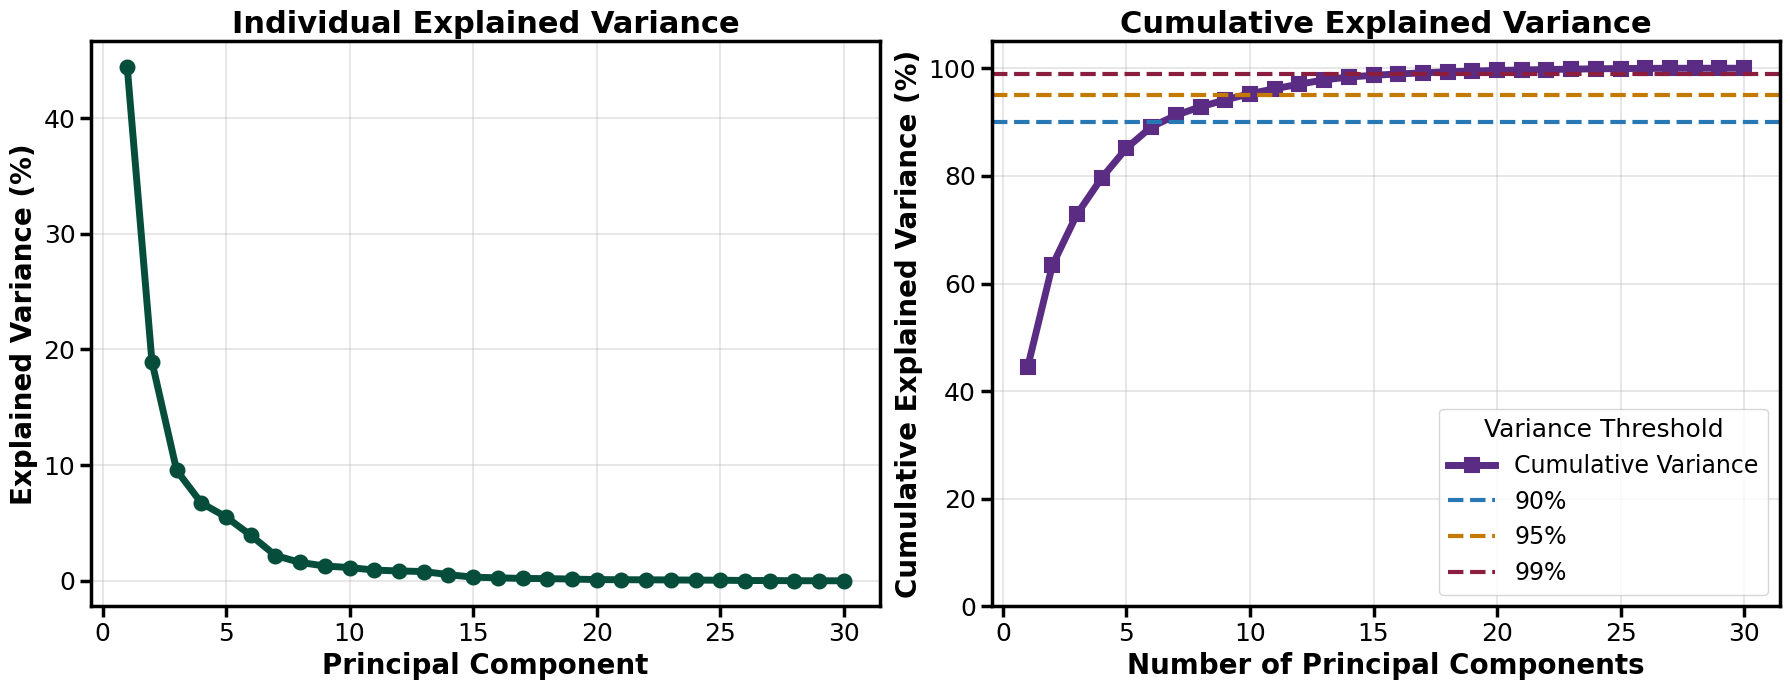

In [ ]:
# breast cancer dataset
plot_explained_variance(
    results_bcancer
)

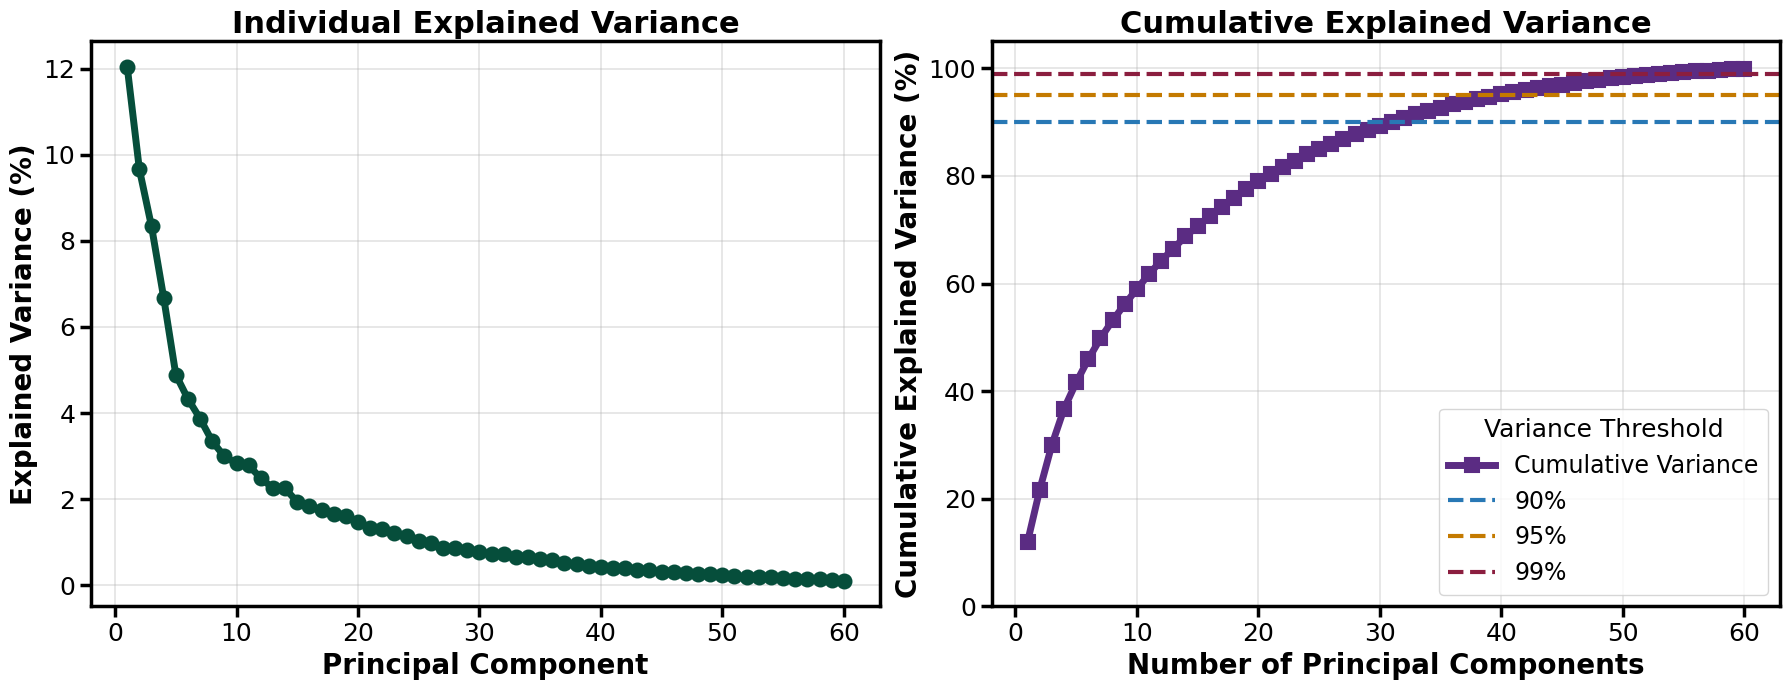

In [ ]:
# digit Dataset
plot_explained_variance(
    results_digits
)


## Visualization of Train and Test accuracy over different Principle Component

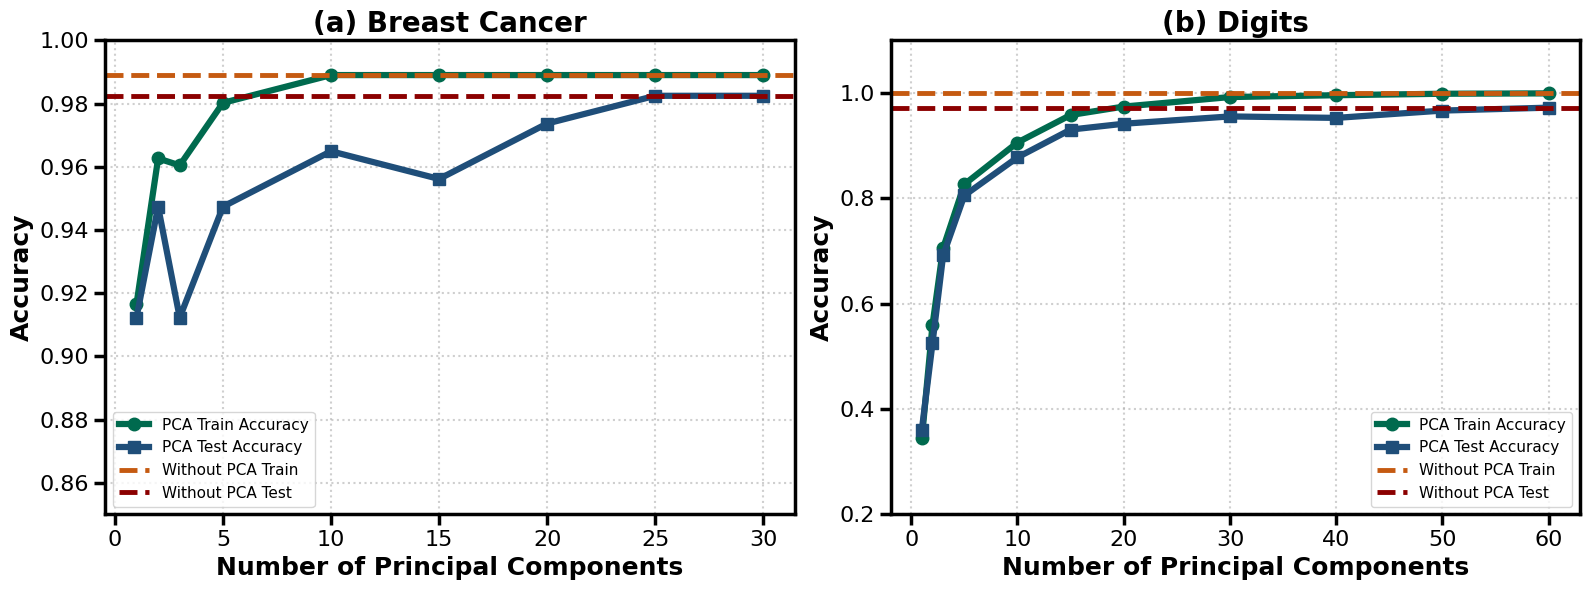

In [ ]:


def plot_model_performance(
    results_bcancer,
    results_digits,
    baseline_bcancer_train,
    baseline_bcancer_test,
    baseline_digits_train,
    baseline_digits_test
):

    # =================================
    # CREATE TWO SUBPLOTS
    # =================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6),
        sharey=False
    )

    datasets = [

        (
            "(a) Breast Cancer",
            results_bcancer,
            baseline_bcancer_train,
            baseline_bcancer_test
        ),

        (
            "(b) Digits",
            results_digits,
            baseline_digits_train,
            baseline_digits_test
        )

    ]

    # =================================
    # PLOT BOTH DATASETS
    # =================================

    for ax, (
        title,
        results,
        baseline_train,
        baseline_test
    ) in zip(
        axes,
        datasets
    ):

        # =================================
        # PCA TRAIN ACCURACY
        # DEEP BOTTLE GREEN
        # =================================

        ax.plot(
            results["Components"],
            results["Train Accuracy"],
            marker="o",
            markersize=9,
            linewidth=4.5,
            color="#006A4E",
            label="PCA Train Accuracy"
        )

        # =================================
        # PCA TEST ACCURACY
        # DARK BLUE
        # =================================

        ax.plot(
            results["Components"],
            results["Test Accuracy"],
            marker="s",
            markersize=9,
            linewidth=4.5,
            color="#1F4E79",
            label="PCA Test Accuracy"
        )

        # =================================
        # WITHOUT PCA TRAIN ACCURACY
        # DARK ORANGE
        # =================================

        ax.axhline(
            baseline_train,
            linestyle="--",
            linewidth=3.5,
            color="#C55A11",
            label="Without PCA Train"
        )

        # =================================
        # WITHOUT PCA TEST ACCURACY
        # DARK RED
        # =================================

        ax.axhline(
            baseline_test,
            linestyle="--",
            linewidth=3.5,
            color="#8B0000",
            label="Without PCA Test"
        )

        # =================================
        # TITLE
        # =================================

        ax.set_title(
            title,
            fontsize=20,
            fontweight="bold"
        )

        # =================================
        # X-AXIS
        # =================================

        ax.set_xlabel(
            "Number of Principal Components",
            fontsize=18,
            fontweight="bold"
        )

        # =================================
        # Y-AXIS
        # =================================

        ax.set_ylabel(
            "Accuracy",
            fontsize=18,
            fontweight="bold"
        )

        # =================================
        # TICKS
        # =================================

        ax.tick_params(
            axis="both",
            labelsize=16,
            width=2.5,
            length=8
        )

        # =================================
        # GRID
        # =================================

        ax.grid(
            linestyle=":",
            linewidth=1.5,
            alpha=0.6
        )

        # =================================
        # SPINES
        # =================================

        for spine in ax.spines.values():
            spine.set_linewidth(2.5)

        # =================================
        # LEGEND
        # =================================

        ax.legend(
            fontsize=11,
            loc="best",
            frameon=True
        )

    # =================================
    # Y-AXIS SCALING
    # =================================

    # Breast Cancer
    axes[0].set_ylim(
        0.85,
        1.00
    )

    # Digits
    axes[1].set_ylim(
        0.20,
        1.10
    )

    # =================================
    # LAYOUT
    # =================================

    plt.tight_layout()

    # =================================
    # SAVE FOR IEEE PAPER
    # =================================

    # plt.savefig(
    #     "PCA_Model_Performance_Comparison.png",
    #     dpi=600,
    #     bbox_inches="tight"
    # )

    plt.show()


# ==================================================
# FUNCTION CALL
# ==================================================

plot_model_performance(

    results_bcancer=results_bcancer,

    results_digits=results_digits,

    baseline_bcancer_train=
        bcancer_result["Train Accuracy"],

    baseline_bcancer_test=
        bcancer_result["Test Accuracy"],

    baseline_digits_train=
        digits_result["Train Accuracy"],

    baseline_digits_test=
        digits_result["Test Accuracy"]
)

## Visualization of Test Accuracy vs Variance Retained

In [ ]:


def plot_variance_vs_accuracy(
    results_bcancer,
    results_digits,
    baseline_bcancer,
    baseline_digits,
    metric="Test Accuracy"
):

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6),
        sharey=True
    )

    datasets = [
        ("(a) Breast Cancer", results_bcancer, baseline_bcancer),
        ("(b) Digits", results_digits, baseline_digits)
    ]

    for ax, (title, results, baseline) in zip(axes, datasets):

        # ==========================================
        # PCA Accuracy Curve
        # ==========================================

        ax.plot(
            results["Variance Retained"] * 100,
            results[metric] * 100,
            color="#00796B",
            linewidth=5,
            marker="o",
            markersize=9,
            label="With PCA"
        )

        # ==========================================
        # Baseline (Without PCA)
        # ==========================================

        ax.axhline(
            baseline * 100,
            color="#E67E22",
            linestyle="--",
            linewidth=4,
            label="Without PCA"
        )

        # ==========================================
        # Find Best PCA Point
        # ==========================================

        best = results.loc[
            results[metric].idxmax()
        ]

        x_best = best["Variance Retained"] * 100
        y_best = best[metric] * 100

        # Gold Star
        ax.scatter(
            x_best,
            y_best,
            s=320,
            marker="*",
            color="#F4B400",
            edgecolor="black",
            linewidth=1.2,
            zorder=5,
            label="Best PCA"
        )

        # ==========================================
        # Annotate Best PCA
        # ==========================================

        ax.annotate(
            f'Best PCA\n'
            f'{int(best["Components"])} PCs\n'
            f'{x_best:.1f}% Var\n'
            f'{y_best:.2f}% Acc',

            (x_best, y_best),

            xytext=(20, -40),

            textcoords="offset points",

            fontsize=13,
            fontweight="bold",

            bbox=dict(
                boxstyle="round,pad=0.35",
                fc="white",
                ec="#00796B",
                alpha=0.95
            ),

            arrowprops=dict(
                arrowstyle="->",
                lw=2,
                color="#00796B"
            )
        )

        # ==========================================
        # Annotate Baseline
        # ==========================================

        ax.text(
            results["Variance Retained"].max() * 100,
            baseline * 100 + 0.25,

            f'No PCA\n{baseline*100:.2f}%',

            fontsize=13,
            color="#E67E22",
            fontweight="bold",

            ha="right",

            bbox=dict(
                facecolor="white",
                edgecolor="#E67E22",
                boxstyle="round,pad=0.3",
                alpha=0.95
            )
        )

        # ==========================================
        # Formatting
        # ==========================================

        ax.set_title(
            title,
            fontsize=20,
            fontweight="bold"
        )

        ax.set_xlabel(
            "Variance Retained (%)",
            fontsize=18,
            fontweight="bold"
        )

        ax.tick_params(
            axis="both",
            labelsize=16,
            width=2.2,
            length=7
        )

        ax.grid(
            linestyle=":",
            linewidth=1.4,
            alpha=0.45
        )

        for spine in ax.spines.values():
            spine.set_linewidth(2)

        ax.legend(
            fontsize=13,
            loc="lower right",
            frameon=True
        )

    axes[0].set_ylabel(
        "Accuracy (%)",
        fontsize=18,
        fontweight="bold"
    )

    # Show y-axis ticks on both plots
    axes[1].tick_params(labelleft=True)

    plt.tight_layout()

    # Uncomment for publication
    # plt.savefig(
    #     "Variance_vs_Accuracy.png",
    #     dpi=600,
    #     bbox_inches="tight"
    # )

    plt.show()

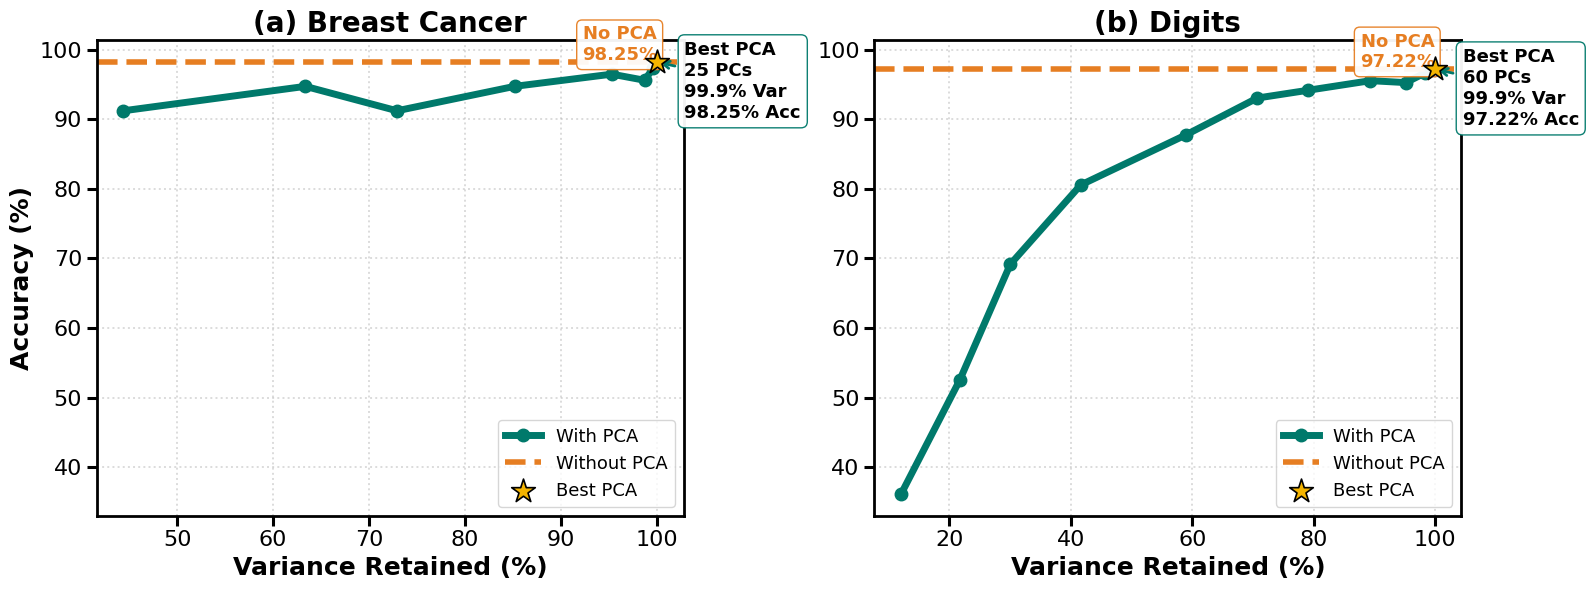

In [ ]:
plot_variance_vs_accuracy(
    results_bcancer,
    results_digits,
    bcancer_result["Test Accuracy"],
    digits_result["Test Accuracy"],
    metric="Test Accuracy"
)

## PCA Projection: Categorywise Scatter plot (PC1 vs PC2) both Breast Cancer and Digit Dataset

In [ ]:
# PCA Projection

def plot_pca_projection(
    X_bcancer,
    y_bcancer,
    X_digits,
    y_digits
):

    # =====================================
    # Standardize
    # =====================================

    scaler_bc = StandardScaler()
    scaler_digit = StandardScaler()

    X_bcancer_scaled = scaler_bc.fit_transform(X_bcancer)
    X_digits_scaled = scaler_digit.fit_transform(X_digits)

    # =====================================
    # PCA (2 Components)
    # =====================================

    pca_bc = PCA(
        n_components=2,
        random_state=42
    )

    pca_digit = PCA(
        n_components=2,
        random_state=42
    )

    X_bcancer_2d = pca_bc.fit_transform(X_bcancer_scaled)
    X_digits_2d = pca_digit.fit_transform(X_digits_scaled)

    # =====================================
    # Figure
    # =====================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6)
    )

    # =====================================
    # (a) Breast Cancer
    # =====================================

    ax = axes[0]

    colors = [
        "#00796B",
        "#E67E22"
    ]

    labels = [
        "Malignant",
        "Benign"
    ]

    for cls, color, label in zip(
        np.unique(y_bcancer),
        colors,
        labels
    ):

        ax.scatter(
            X_bcancer_2d[y_bcancer == cls, 0],
            X_bcancer_2d[y_bcancer == cls, 1],
            s=35,
            alpha=0.75,
            color=color,
            label=label
        )

    ax.set_title(
        "(a) Breast Cancer",
        fontsize=20,
        fontweight="bold"
    )

    ax.set_xlabel(
        f"PC1 ({pca_bc.explained_variance_ratio_[0]*100:.1f}%)",
        fontsize=18,
        fontweight="bold"
    )

    ax.set_ylabel(
        f"PC2 ({pca_bc.explained_variance_ratio_[1]*100:.1f}%)",
        fontsize=18,
        fontweight="bold"
    )

    ax.legend(
        fontsize=14,
        loc="best",
        frameon=True
    )

    # =====================================
    # (b) Digits
    # =====================================

    ax = axes[1]

    scatter = ax.scatter(
        X_digits_2d[:, 0],
        X_digits_2d[:, 1],
        c=y_digits,
        cmap="tab10",
        s=30,
        alpha=0.75
    )

    ax.set_title(
        "(b) Digits",
        fontsize=20,
        fontweight="bold"
    )

    ax.set_xlabel(
        f"PC1 ({pca_digit.explained_variance_ratio_[0]*100:.1f}%)",
        fontsize=18,
        fontweight="bold"
    )

    ax.set_ylabel(
        f"PC2 ({pca_digit.explained_variance_ratio_[1]*100:.1f}%)",
        fontsize=18,
        fontweight="bold"
    )

    cbar = fig.colorbar(
        scatter,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    cbar.set_label(
        "Digit Class",
        fontsize=16,
        fontweight="bold"
    )

    cbar.ax.tick_params(
        labelsize=13
    )

    # =====================================
    # Formatting
    # =====================================

    for ax in axes:

        ax.tick_params(
            axis="both",
            labelsize=15,
            width=2,
            length=7
        )

        ax.grid(
            linestyle=":",
            linewidth=1.2,
            alpha=0.35
        )

        for spine in ax.spines.values():
            spine.set_linewidth(2)

    plt.tight_layout()

    # Uncomment for IEEE paper
    # plt.savefig(
    #     "PCA_Projection_Both_Datasets.png",
    #     dpi=600,
    #     bbox_inches="tight"
    # )

    plt.show()

    return (
        pca_bc,
        pca_digit,
        X_bcancer_2d,
        X_digits_2d
    )

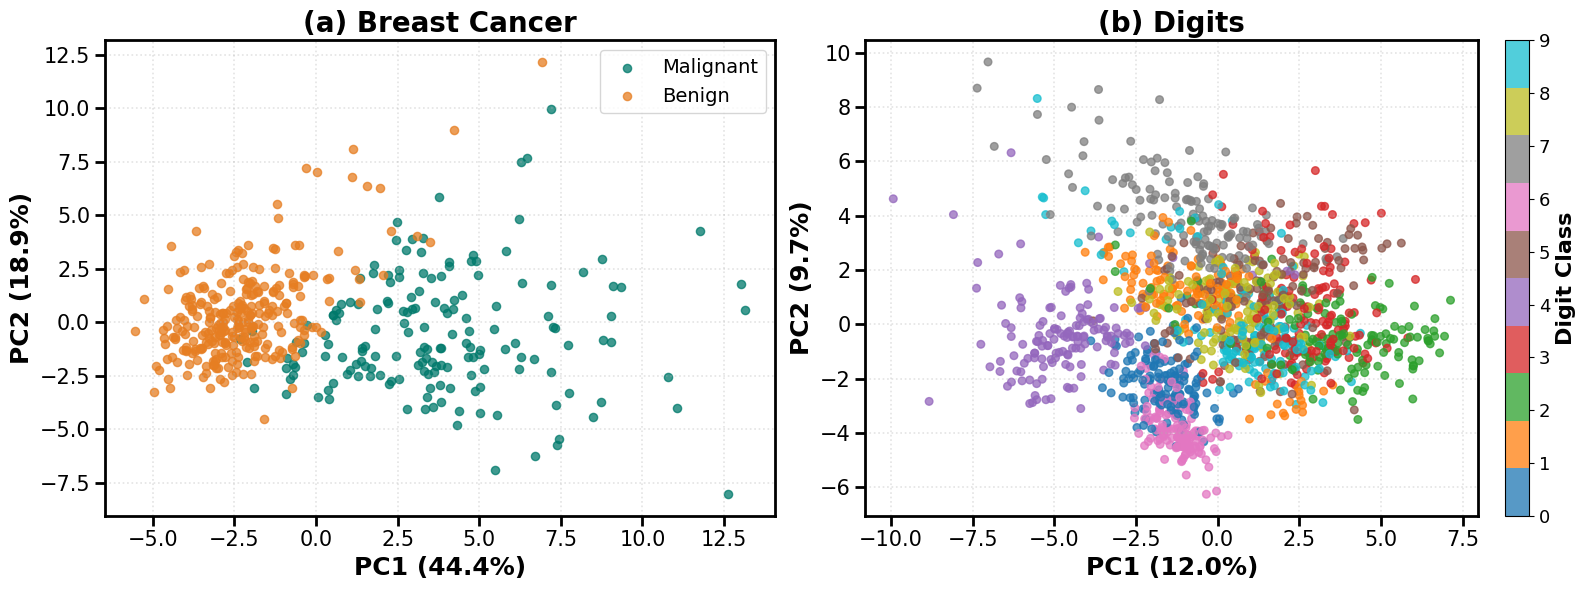

In [ ]:

#Categorywise Scatter plot (PC1 vs PC2)
pca_bcancer, pca_digits, X_bcancer_2d, X_digits_2d = plot_pca_projection(
    X_bcancer_train,
    y_bcancer_train,
    X_digits_train,
    y_digits_train
)

## Reconstraction (Pixel Intensisty plot for Digit Dataset)

In [ ]:



def reconstruct_digits(
    X, sample_index=0, component_list=[5, 10, 20, 40], cmap="viridis"
):
    """Visualize PCA reconstruction of a handwritten digit.

    Parameters
    ----------
    X : DataFrame or ndarray
        Original digits dataset (64 features).
    sample_index : int
        Index of the image to reconstruct.
    component_list : list
        Numbers of principal components to reconstruct with.
    cmap : str
        Matplotlib colormap.
    """
    # Standardize input format
    X_array = X.values if hasattr(X, "iloc") else np.asarray(X)

    # ------------------------------------------
    # Standardize
    # ------------------------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_array)

    original_image = X_array[sample_index].reshape(8, 8)

    # ------------------------------------------
    # Plot setup with dedicated colorbar column
    # ------------------------------------------
    n_images = len(component_list) + 1
    # Create equal-width columns for images + 1 narrow column for the colorbar
    width_ratios = [1] * n_images + [0.04]

    fig, axes = plt.subplots(
        1,
        n_images + 1,
        figsize=(3.5 * n_images + 0.5, 4),
        gridspec_kw={"width_ratios": width_ratios},
    )

    image_axes = axes[:-1]
    cax = axes[-1]  # Dedicated colorbar axis

    # ==========================================
    # Original Image
    # ==========================================
    im = image_axes[0].imshow(
        original_image, cmap=cmap, interpolation="nearest"
    )
    image_axes[0].set_title("Original", fontsize=20, fontweight="bold")
    image_axes[0].axis("off")

    # ==========================================
    # PCA Reconstructions
    # ==========================================
    for ax, n_components in zip(image_axes[1:], component_list):
        pca = PCA(n_components=n_components, random_state=42)
        X_reduced = pca.fit_transform(X_scaled)
        X_reconstructed = pca.inverse_transform(X_reduced)

        # Back to original pixel scale
        X_reconstructed = scaler.inverse_transform(X_reconstructed)
        reconstructed = X_reconstructed[sample_index].reshape(8, 8)

        im = ax.imshow(reconstructed, cmap=cmap, interpolation="nearest")
        variance = pca.explained_variance_ratio_.sum() * 100

        ax.set_title(
            f"{n_components} PCs\n({variance:.1f}%)",
            fontsize=20,
            fontweight="bold",
        )
        ax.axis("off")

    # ==========================================
    # Colorbar in its own axis
    # ==========================================
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Pixel Intensity", fontsize=18, fontweight="bold")
    cbar.ax.tick_params(labelsize=10)

    plt.tight_layout()
    plt.show()

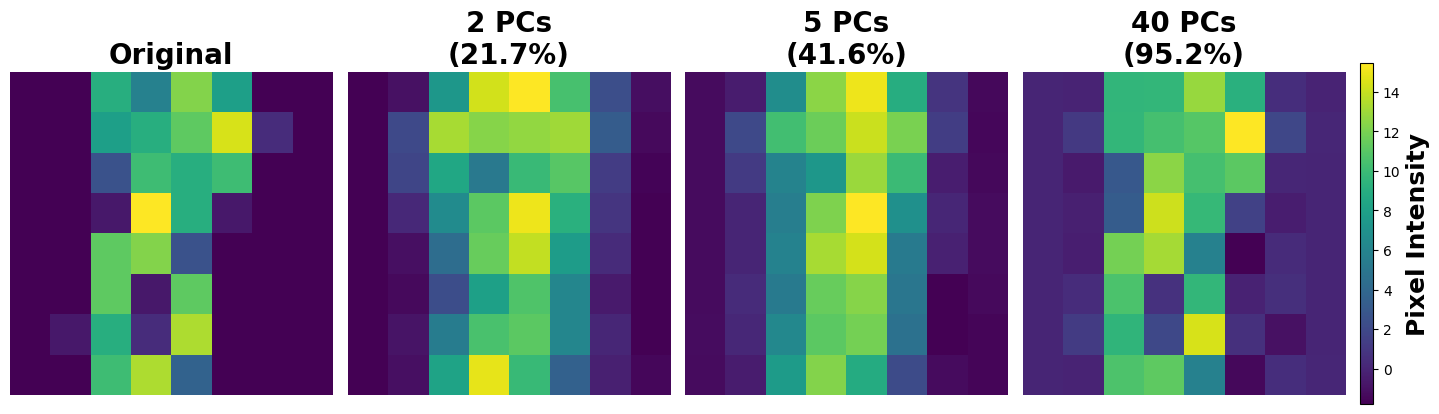

In [ ]:
# Call reconstruction Function
reconstruct_digits(
    X_digits_train,
    sample_index=10,
    component_list=[
        2, 5, 40
    ]
)

## Visualization of Reconstruction Error

In [ ]:

# reconstruction error Function
def reconstruction_error(
    X,
    component_list
):

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(
        X
    )

    errors = []

    for n_components in component_list:

        pca = PCA(
            n_components=n_components
        )

        X_reduced = pca.fit_transform(
            X_scaled
        )

        X_reconstructed = (
            pca.inverse_transform(
                X_reduced
            )
        )

        mse = np.mean(
            (
                X_scaled
                -
                X_reconstructed
            ) ** 2
        )

        errors.append({
            "Components": n_components,
            "Reconstruction Error": mse
        })

    return pd.DataFrame(errors)

In [ ]:
reconstruction_results = reconstruction_error(
    X_digits_train,
    [2, 5, 10, 20, 30, 40, 50]
)

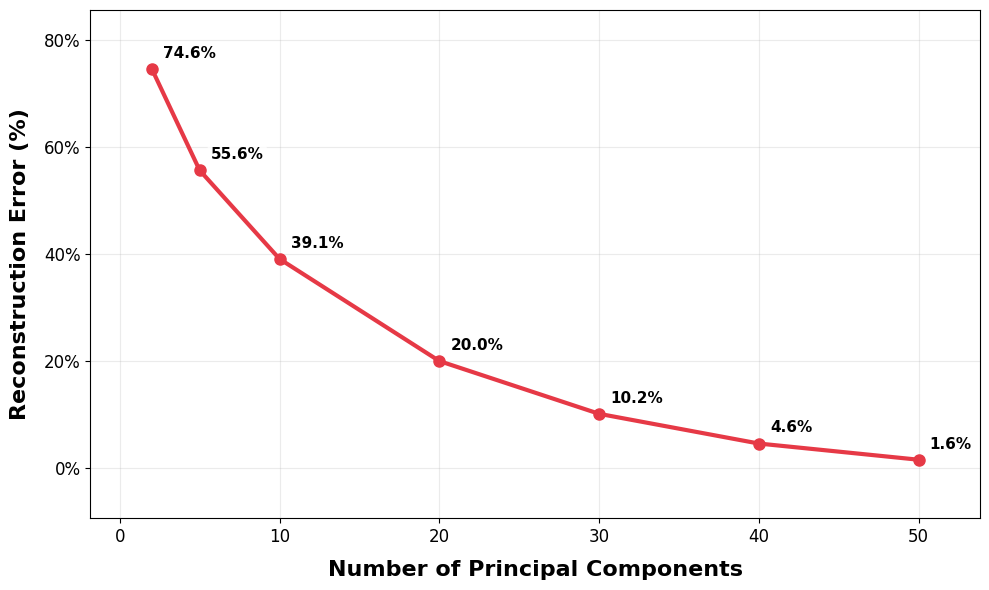

In [ ]:

# Reconstruction Error
plt.figure(figsize=(10, 6))

components = reconstruction_results["Components"]
errors = reconstruction_results["Reconstruction Error"]

plt.plot(
    components,
    errors,
    marker="o",
    markersize=8,
    linewidth=3,
    color="#e63946",  # Vibrant coral red
)

# Annotate each point as a percentage (multiply by 100)
for x, y in zip(components, errors):
    plt.annotate(
        f"{y * 100:.1f}%",  # Use :.3f% if you prefer 3 decimal places (e.g., 75.000%)
        (x, y),
        textcoords="offset points",
        xytext=(8, 8),
        ha="left",
        fontsize=11,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="none",
            alpha=0.8,
        ),
    )

# Format Y-axis ticks where 1.0 = 100%
gca = plt.gca()
gca.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1.0, decimals=0)
)

# Axis labels
plt.xlabel(
    "Number of Principal Components",
    fontsize=16,
    fontweight="bold",
    labelpad=10,
)

plt.ylabel(
    "Reconstruction Error (%)",
    fontsize=16,
    fontweight="bold",
    labelpad=10,
)

# Tick labels
plt.tick_params(axis="both", which="major", labelsize=12)

# Adjust margins so top/right labels aren't cut off
plt.margins(x=0.08, y=0.15)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Ultimate Summary Table

In [ ]:


def create_final_comparison_table(
    results,
    dataset_name,
    original_features,
    baseline_results
):

    # =====================================
    # PCA RESULTS
    # =====================================

    pca_table = results.copy()

    pca_table["Dataset"] = dataset_name
    pca_table["Method"] = "PCA"
    pca_table["Original Features"] = original_features

    # Explained Variance (%)
    pca_table["Explained Variance (%)"] = (
        pca_table["Variance Retained"] * 100
    )

    # Percentage Columns
    pca_table["Variance Retained (%)"] = (
        pca_table["Variance Retained"] * 100
    )

    pca_table["Train Accuracy (%)"] = (
        pca_table["Train Accuracy"] * 100
    )

    pca_table["Test Accuracy (%)"] = (
        pca_table["Test Accuracy"] * 100
    )

    pca_table["Test F1 (%)"] = (
        pca_table["Test F1"] * 100
    )

    pca_table["Dimensionality Reduction (%)"] = (
        (1 - pca_table["Components"] / original_features) * 100
    )

    # Rename Training Time column
    pca_table = pca_table.rename(
        columns={
            "Training Time": "Training Time (s)"
        }
    )

    # =====================================
    # WITHOUT PCA
    # =====================================

    baseline_row = pd.DataFrame({

        "Dataset": [dataset_name],

        "Method": ["Without PCA"],

        "Original Features": [original_features],

        "Components": [original_features],

        "Explained Variance (%)": [100.0],

        "Variance Retained (%)": [100.0],

        "Train Accuracy (%)": [
            baseline_results["Train Accuracy"] * 100
        ],

        "Test Accuracy (%)": [
            baseline_results["Test Accuracy"] * 100
        ],

        "Test F1 (%)": [
            baseline_results["Test F1"] * 100
        ],

        "Training Time (s)": [
            baseline_results["Training Time"]
        ],

        "Dimensionality Reduction (%)": [
            0.0
        ]
    })

    # =====================================
    # Keep Columns
    # =====================================

    columns = [
        "Dataset",
        "Method",
        "Original Features",
        "Components",
        "Explained Variance (%)",
        "Variance Retained (%)",
        "Train Accuracy (%)",
        "Test Accuracy (%)",
        "Test F1 (%)",
        "Training Time (s)",
        "Dimensionality Reduction (%)"
    ]

    pca_table = pca_table[columns]

    # =====================================
    # Combine
    # =====================================

    final_table = pd.concat(
        [baseline_row, pca_table],
        ignore_index=True
    )

    # =====================================
    # Round Values
    # =====================================

    final_table = final_table.round({
        "Explained Variance (%)": 2,
        "Variance Retained (%)": 2,
        "Train Accuracy (%)": 2,
        "Test Accuracy (%)": 2,
        "Test F1 (%)": 2,
        "Training Time (s)": 4,
        "Dimensionality Reduction (%)": 2
    })

    return final_table

In [ ]:
# Breast Cancer Comparison Table
comparison_bcancer = create_final_comparison_table(
    results=results_bcancer,
    dataset_name="Breast Cancer",
    original_features=X_bcancer_train.shape[1],
    baseline_results=bcancer_result
)

comparison_bcancer

,Dataset,Method,Original Features,Components,Explained Variance (%),Variance Retained (%),Train Accuracy (%),Test Accuracy (%),Test F1 (%),Training Time (s),Dimensionality Reduction (%)
0,Breast Cancer,Without PCA,30,30,100.00,100.00,98.90,98.25,98.25,0.1245,0.00
1,Breast Cancer,PCA,30,1,44.41,44.41,91.65,91.23,91.23,0.0198,96.67
2,Breast Cancer,PCA,30,2,63.36,63.36,96.26,94.74,94.76,0.0134,93.33
3,Breast Cancer,PCA,30,3,72.90,72.90,96.04,91.23,91.30,0.0127,90.00
4,Breast Cancer,PCA,30,5,85.14,85.14,98.02,94.74,94.76,0.0196,83.33
5,Breast Cancer,PCA,30,10,95.27,95.27,98.90,96.49,96.51,0.0333,66.67
6,Breast Cancer,PCA,30,15,98.68,98.68,98.90,95.61,95.64,0.0422,50.00
7,Breast Cancer,PCA,30,20,99.58,99.58,98.90,97.37,97.37,0.0748,33.33
8,Breast Cancer,PCA,30,25,99.95,99.95,98.90,98.25,98.25,0.0318,16.67
9,Breast Cancer,PCA,30,30,100.00,100.00,98.90,98.25,98.25,0.0701,0.00


In [ ]:
# Digits Comparison Table
comparison_digits = create_final_comparison_table(
    results=results_digits,
    dataset_name="Digits",
    original_features=X_digits_train.shape[1],
    baseline_results=digits_result
)

comparison_digits

,Dataset,Method,Original Features,Components,Explained Variance (%),Variance Retained (%),Train Accuracy (%),Test Accuracy (%),Test F1 (%),Training Time (s),Dimensionality Reduction (%)
0,Digits,Without PCA,64,64,100.00,100.00,99.93,97.22,97.22,0.4655,0.00
1,Digits,PCA,64,1,12.04,12.04,34.45,36.11,33.14,0.2173,98.44
2,Digits,PCA,64,2,21.70,21.70,55.95,52.50,50.70,0.3957,96.88
3,Digits,PCA,64,3,30.04,30.04,70.56,69.17,68.17,0.2740,95.31
4,Digits,PCA,64,5,41.62,41.62,82.67,80.56,80.11,0.2104,92.19
5,Digits,PCA,64,10,58.98,58.98,90.61,87.78,87.56,0.2358,84.38
6,Digits,PCA,64,15,70.69,70.69,95.82,93.06,93.02,0.2670,76.56
7,Digits,PCA,64,20,78.99,78.99,97.43,94.17,94.13,0.1937,68.75
8,Digits,PCA,64,30,89.33,89.33,99.23,95.56,95.57,0.2820,53.12
9,Digits,PCA,64,40,95.16,95.16,99.58,95.28,95.29,0.8248,37.50


In [ ]:
final_comparison = pd.concat(
    [
        comparison_bcancer,
        comparison_digits
    ],
    ignore_index=True
)

final_comparison

,Dataset,Method,Original Features,Components,Explained Variance (%),Variance Retained (%),Train Accuracy (%),Test Accuracy (%),Test F1 (%),Training Time (s),Dimensionality Reduction (%)
0,Breast Cancer,Without PCA,30,30,100.00,100.00,98.90,98.25,98.25,0.1245,0.00
1,Breast Cancer,PCA,30,1,44.41,44.41,91.65,91.23,91.23,0.0198,96.67
2,Breast Cancer,PCA,30,2,63.36,63.36,96.26,94.74,94.76,0.0134,93.33
3,Breast Cancer,PCA,30,3,72.90,72.90,96.04,91.23,91.30,0.0127,90.00
4,Breast Cancer,PCA,30,5,85.14,85.14,98.02,94.74,94.76,0.0196,83.33
5,Breast Cancer,PCA,30,10,95.27,95.27,98.90,96.49,96.51,0.0333,66.67
6,Breast Cancer,PCA,30,15,98.68,98.68,98.90,95.61,95.64,0.0422,50.00
7,Breast Cancer,PCA,30,20,99.58,99.58,98.90,97.37,97.37,0.0748,33.33
8,Breast Cancer,PCA,30,25,99.95,99.95,98.90,98.25,98.25,0.0318,16.67
9,Breast Cancer,PCA,30,30,100.00,100.00,98.90,98.25,98.25,0.0701,0.00


### Visualization of Training Time and Dim Reduction

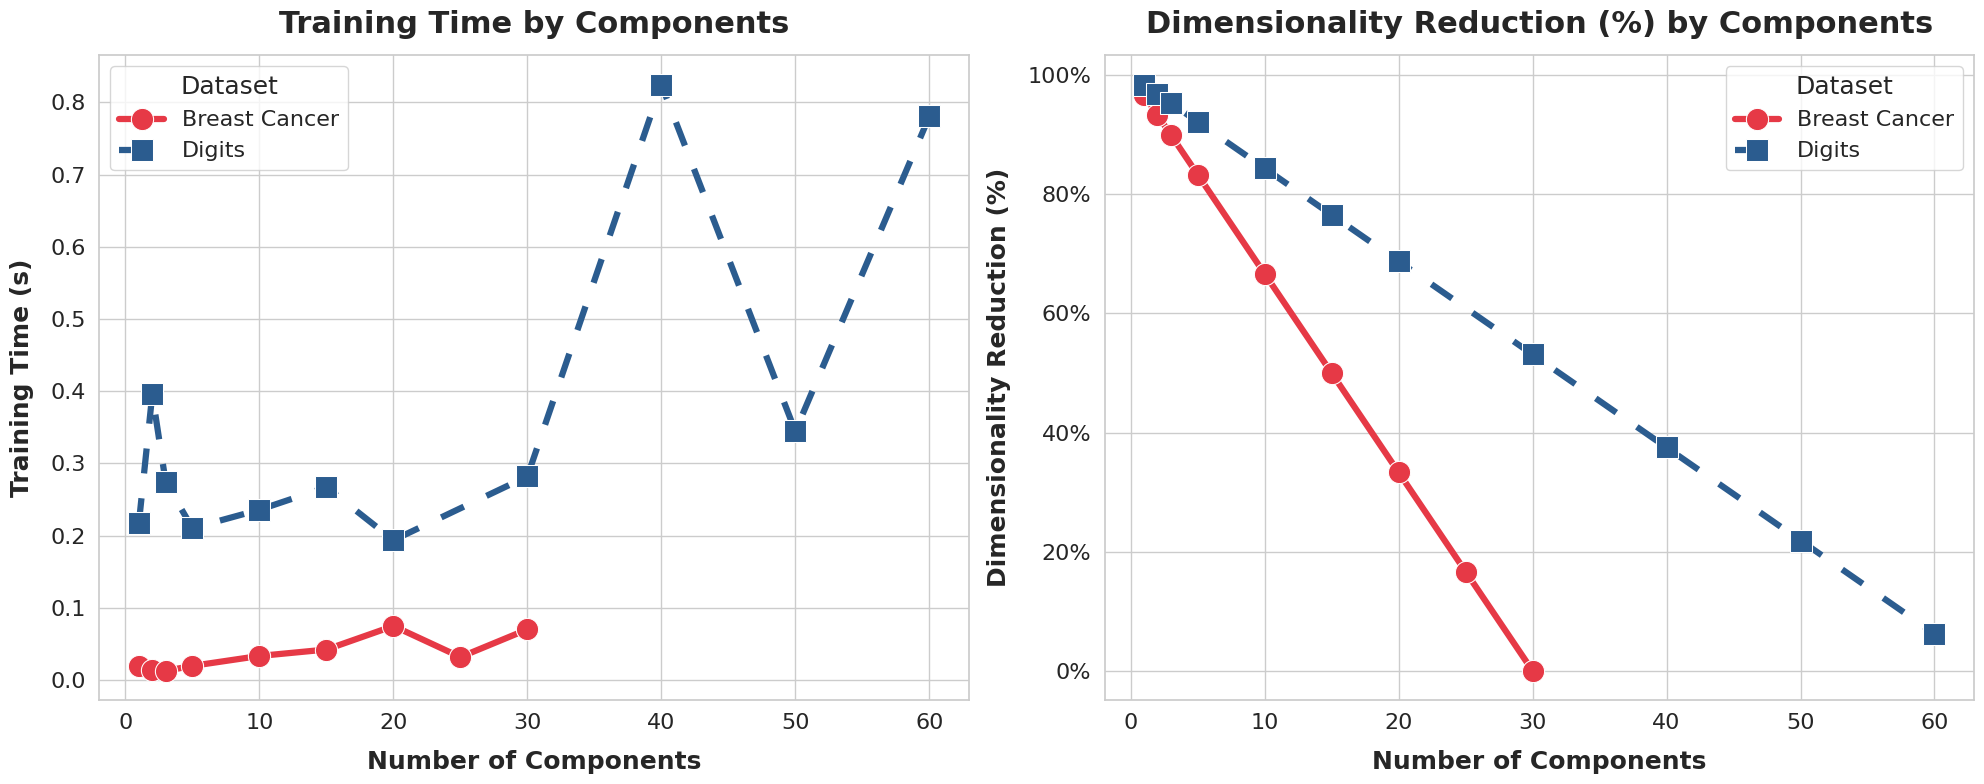

In [ ]:

# Set publication-quality style
sns.set_theme(style="whitegrid")

# Create a figure with 2 side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Colors for the two datasets
palette = {"Breast Cancer": "#e63946", "Digits": "#2b5c8f"}

# Filter for PCA methods to ensure clean line plotting
plot_df = final_comparison[final_comparison["Method"] == "PCA"]

# ==========================================
# 1. Training Time vs Components
# ==========================================
sns.lineplot(
    data=plot_df,
    x="Components",
    y="Training Time (s)",
    hue="Dataset",
    style="Dataset",
    ax=axes[0],
    palette=palette,
    markers=["o", "s"],
    dashes=[(None, None), (4, 4)],  # Solid for Cancer, Dashed for Digits
    linewidth=4.5,
    markersize=16,
)

axes[0].set_title(
    "Training Time by Components", fontsize=22, fontweight="bold", pad=16
)
axes[0].set_xlabel(
    "Number of Components", fontsize=18, fontweight="bold", labelpad=12
)
axes[0].set_ylabel(
    "Training Time (s)", fontsize=18, fontweight="bold", labelpad=12
)
axes[0].tick_params(axis="both", which="major", labelsize=16)

# ==========================================
# 2. Dimensionality Reduction (%) vs Components
# ==========================================
sns.lineplot(
    data=plot_df,
    x="Components",
    y="Dimensionality Reduction (%)",
    hue="Dataset",
    style="Dataset",
    ax=axes[1],
    palette=palette,
    markers=["o", "s"],
    dashes=[(None, None), (4, 4)],
    linewidth=4.5,
    markersize=16,
)

axes[1].set_title(
    "Dimensionality Reduction (%) by Components",
    fontsize=22,
    fontweight="bold",
    pad=16,
)
axes[1].set_xlabel(
    "Number of Components", fontsize=18, fontweight="bold", labelpad=12
)
axes[1].set_ylabel(
    "Dimensionality Reduction (%)", fontsize=18, fontweight="bold", labelpad=12
)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
axes[1].tick_params(axis="both", which="major", labelsize=16)

# ==========================================
# Format Legends
# ==========================================
# Left subplot
axes[0].legend(
    title="Dataset",
    title_fontsize=18,
    fontsize=16,
    loc="upper left",
)

# Right subplot
axes[1].legend(
    title="Dataset",
    title_fontsize=18,
    fontsize=16,
    loc="upper right",
)
plt.tight_layout()
plt.show()

## Discussion:

The main findings of this study are summarized as follows:

- Feature Structure: The Breast Cancer dataset showed
stronger overall feature relationships than the Digits
dataset, based on its higher mean absolute correlation and
KMO value.
- Breast Cancer Dataset: Ten components retained
95.27% of the variance with 66.67% dimensionality re-
duction and achieved 96.49% test accuracy. Increasing
to 25 components retained 99.95% of the variance and
recovered the 98.25% baseline accuracy.
- Digits Dataset: The Digits dataset required more com-
ponents to preserve comparable information. Fifty com-
ponents retained 98.33% of the variance with 21.88%
dimensionality reduction and achieved 96.67% test accu-
racy, while 60 components matched the 97.22% baseline.
- Performance Trade-off: Increasing the number of com-
ponents consistently increased variance retention, but
classification performance did not always improve. This
showed that variance retention and predictive perfor-
mance were related but not identical..
- Overall Finding: PCA effectiveness depended on the
feature structure of the dataset. Therefore, component
selection should balance variance retention, classification
performance, reconstruction quality, and dimensionality
reduction








## Conclusion
This study showed that PCA reduced feature dimensionality while preserving useful information and classification performance, although its effectiveness depended on the feature structure. For the Breast Cancer dataset, 10 components retained 95.27% of the variance with 66.67% dimensionality reduction and achieved 96.49% test accuracy, while 25 components retained 99.95% variance and recovered the 98.25% baseline accuracy. For the Digits dataset, 50 components retained 98.33% variance with 21.88% dimensionality reduction and achieved 96.67% test accuracy, while 60 component retained 99.92% variance and matched the 97.22% baseline. These results showed that PCA component selection should jointly consider variance retention, predictive performance, and dimensionality reduction rather than relying on a single criterion.